# NLP Assignment 3

# Part A

In [36]:
import math
import re
from collections import Counter
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42)

DATA_FILES = {
    "train": "train.csv",
    "val": "val.csv",
    "test": "test.csv",
}

MAX_LEN = 128
MIN_FREQ = 2
BATCH_SIZE = 64
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1

Using device: cpu


##  create labels

In [26]:
def rating_to_sentiment(rating: int) -> int:
    #    maps ratings into the required 3 sentiment classes.
    if rating <= 2:
        return 0  # Negative
    if rating == 3:
        return 1  # Neutral
    return 2      # Positive


def load_split(path: str) -> pd.DataFrame:
    #    loads one CSV split and keeps only needed columns.
    df = pd.read_csv(path)
    df = df[["review_text", "rating", "category"]].copy()
    df["rating"] = df["rating"].astype(int)
    df["sentiment_label"] = df["rating"].apply(rating_to_sentiment)
    return df


splits = {name: load_split(path) for name, path in DATA_FILES.items()}

for name, df in splits.items():
    print(f"{name}: {len(df)} samples")

splits["train"].head(2)

train: 25200 samples
val: 5400 samples
test: 5400 samples


,review_text,rating,category,sentiment_label
0,Love this spray!! Hold and great shine all in ...,5,Beauty,2
1,I got the 16-ga 100' spool. It arrived on tim...,5,Electronics,2


## Tokenize text and build vocabulary from training data only

Clean text (lowercase and spaces), tokenize, build vocab from train only, convert to indices, then pad or truncate to fixed MAX_LEN.

In [27]:
def clean_text(text: str) -> str:
    #    lightly normalizes text to make tokenization consistent.
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def tokenize(text: str) -> list[str]:
    #    splits text into basic word-like tokens.
    text = clean_text(text)
    return re.findall(r"[a-z0-9']+", text)


def build_vocab(train_texts: pd.Series, min_freq: int = 2) -> tuple[dict[str, int], dict[int, str]]:
    #    builds a vocabulary only from training split tokens.
    counter = Counter()
    for text in train_texts:
        counter.update(tokenize(text))

    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = len(vocab)

    itos = {idx: token for token, idx in vocab.items()}
    return vocab, itos


def review_length(text: str) -> int:
    #    counts tokens in a review after cleaning.
    return len(tokenize(text))


def add_length_label(splits: dict[str, pd.DataFrame]) -> int:
    #    adds a short/long label using the training median length threshold.
    train_lengths = splits["train"]["review_text"].apply(review_length)
    threshold = int(train_lengths.median())

    for split_name, df in splits.items():
        lengths = df["review_text"].apply(review_length)
        df["length_label"] = (lengths >= threshold).astype(int)
        print(f"{split_name} length label counts: {df['length_label'].value_counts().to_dict()}")

    return threshold


length_threshold = add_length_label(splits)
vocab, itos = build_vocab(splits["train"]["review_text"], min_freq=MIN_FREQ)
print(f"Length threshold (train median tokens): {length_threshold}")
print(f"Vocab size (train only): {len(vocab)}")
print("Sample tokens:", list(vocab.keys())[2:12])

train length label counts: {1: 12769, 0: 12431}
val length label counts: {1: 2746, 0: 2654}
test length label counts: {1: 2781, 0: 2619}
Length threshold (train median tokens): 58
Vocab size (train only): 22827
Sample tokens: ['love', 'this', 'spray', 'hold', 'and', 'great', 'shine', 'all', 'in', 'one']


## Convert tokens to indices and apply fixed padding 

In [28]:
def tokens_to_indices(tokens: list[str], vocab: dict[str, int]) -> list[int]:
    #    changes tokens into integer ids using the vocabulary.
    return [vocab.get(tok, UNK_IDX) for tok in tokens]


def pad_or_truncate(ids: list[int], max_len: int, pad_idx: int = PAD_IDX) -> tuple[list[int], list[int]]:
    #    makes every sequence the same fixed length.
    if len(ids) >= max_len:
        trimmed = ids[:max_len]
        mask = [1] * max_len
        return trimmed, mask

    pad_count = max_len - len(ids)
    padded = ids + [pad_idx] * pad_count
    mask = [1] * len(ids) + [0] * pad_count
    return padded, mask


def preprocess_split(df: pd.DataFrame, vocab: dict[str, int], max_len: int) -> dict[str, torch.Tensor]:
    #    preprocesses one split into tensors for model input.
    input_ids, attention_masks = [], []

    for text in df["review_text"]:
        tokens = tokenize(text)
        token_ids = tokens_to_indices(tokens, vocab)
        ids_fixed, mask_fixed = pad_or_truncate(token_ids, max_len=max_len)
        input_ids.append(ids_fixed)
        attention_masks.append(mask_fixed)

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
        "sentiment_label": torch.tensor(df["sentiment_label"].to_numpy(), dtype=torch.long),
        "length_label": torch.tensor(df["length_label"].to_numpy(), dtype=torch.long),
    }


preprocessed = {
    split_name: preprocess_split(df, vocab=vocab, max_len=MAX_LEN)
    for split_name, df in splits.items()
}

for split_name, data_dict in preprocessed.items():
    print(
        split_name,
        data_dict["input_ids"].shape,
        data_dict["attention_mask"].shape,
        data_dict["sentiment_label"].shape,
        data_dict["length_label"].shape,
    )

train torch.Size([25200, 128]) torch.Size([25200, 128]) torch.Size([25200]) torch.Size([25200])
val torch.Size([5400, 128]) torch.Size([5400, 128]) torch.Size([5400]) torch.Size([5400])
test torch.Size([5400, 128]) torch.Size([5400, 128]) torch.Size([5400]) torch.Size([5400])


## Build dataloaders from the preprocessed tensors

In [29]:
def build_dataloader(split_dict: dict[str, torch.Tensor], batch_size: int, shuffle: bool) -> DataLoader:
    #    wraps processed tensors into a PyTorch dataloader.
    ds = TensorDataset(
        split_dict["input_ids"],
        split_dict["attention_mask"],
        split_dict["sentiment_label"],
        split_dict["length_label"],
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


loaders = {
    "train": build_dataloader(preprocessed["train"], BATCH_SIZE, shuffle=True),
    "val": build_dataloader(preprocessed["val"], BATCH_SIZE, shuffle=False),
    "test": build_dataloader(preprocessed["test"], BATCH_SIZE, shuffle=False),
}

batch = next(iter(loaders["train"]))
print("Batch tensor shapes:", [x.shape for x in batch])

Batch tensor shapes: [torch.Size([64, 128]), torch.Size([64, 128]), torch.Size([64]), torch.Size([64])]


## Implement Transformer Encoder 

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        #    precomputes sinusoidal positions once for fast reuse.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #    adds position information to token embeddings.
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        #    checks dimensions and prepares projection layers.
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        #    reshapes vectors into independent attention heads.
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        #    merges all heads back into one vector per token.
        batch_size, _, seq_len, _ = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        #    computes self-attention using Q, K, and V projections.
        q = self._split_heads(self.q_proj(x))
        k = self._split_heads(self.k_proj(x))
        v = self._split_heads(self.v_proj(x))

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2).to(dtype=torch.bool)
            scores = scores.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(scores, dim=-1)

        if attention_mask is not None:
            # Re-mask and re-normalize to avoid NaNs when a query has all keys masked.
            attn_weights = attn_weights * mask.float()
            attn_weights = attn_weights / attn_weights.sum(dim=-1, keepdim=True).clamp_min(1e-9)

        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, v)
        context = self._combine_heads(context)
        return self.out_proj(context)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        #    builds a small two-layer network for each token.
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #    applies the feed-forward network token by token.
        return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        #    creates one encoder block with attention and feed-forward parts.
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        #    applies residual connections and layer normalization in order.
        attn_out = self.self_attn(x, attention_mask)
        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x


class EncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        num_heads: int = 4,
        ff_dim: int = 256,
        num_layers: int = 2,
        max_len: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        #    assembles token embedding, positional encoding, and encoder stack.
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.position_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        )

    def masked_mean_pool(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        #    computes one fixed review vector by averaging valid tokens only.
        mask = attention_mask.unsqueeze(-1).float()
        summed = torch.sum(x * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        #    returns token-level outputs and one pooled review embedding.
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, attention_mask)

        pooled = self.masked_mean_pool(x, attention_mask)
        return x, pooled

##  encoder model 

In [37]:
encoder_model = EncoderTransformer(
    vocab_size=len(vocab),
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_len=MAX_LEN,
    dropout=0.1,
)
sample_input_ids, sample_mask, _, _ = next(iter(loaders["train"]))

with torch.no_grad():
    token_outputs, review_embeddings = encoder_model(sample_input_ids, sample_mask)

print("Token outputs shape:", token_outputs.shape)    
print("Review embeddings shape:", review_embeddings.shape) 

Token outputs shape: torch.Size([64, 128, 128])
Review embeddings shape: torch.Size([64, 128])


##   build three-class derived labels and dataloaders

Derived feature is review length class (short, medium, long), which is meaningful from text content and useful with sentiment.

In [38]:
import numpy as np


def add_length3_labels(splits: dict[str, pd.DataFrame]) -> tuple[int, int]:
    # makes short medium long labels using train token length quantiles.
    train_lengths = splits["train"]["review_text"].apply(review_length)
    q1 = int(train_lengths.quantile(1 / 3))
    q2 = int(train_lengths.quantile(2 / 3))

    if q2 <= q1:
        q2 = q1 + 1

    for split_name, df in splits.items():
        lengths = df["review_text"].apply(review_length)
        labels = np.where(lengths < q1, 0, np.where(lengths < q2, 1, 2)).astype(int)
        df["length3_label"] = labels
        print(f"{split_name} length3 counts: {df['length3_label'].value_counts().to_dict()}")

    return q1, q2


def preprocess_split_multitask(df: pd.DataFrame, vocab: dict[str, int], max_len: int) -> dict[str, torch.Tensor]:
    # converts one split into tensors for both sentiment and derived tasks.
    input_ids, attention_masks = [], []

    for text in df["review_text"]:
        tokens = tokenize(text)
        token_ids = tokens_to_indices(tokens, vocab)
        ids_fixed, mask_fixed = pad_or_truncate(token_ids, max_len=max_len)
        input_ids.append(ids_fixed)
        attention_masks.append(mask_fixed)

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
        "sentiment_label": torch.tensor(df["sentiment_label"].to_numpy(), dtype=torch.long),
        "derived_label": torch.tensor(df["length3_label"].to_numpy(), dtype=torch.long),
    }


def build_multitask_dataloader(split_dict: dict[str, torch.Tensor], batch_size: int, shuffle: bool) -> DataLoader:
    # wraps multitask tensors into a dataloader for training and evaluation.
    ds = TensorDataset(
        split_dict["input_ids"],
        split_dict["attention_mask"],
        split_dict["sentiment_label"],
        split_dict["derived_label"],
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


q1_len, q2_len = add_length3_labels(splits)
print(f"Length bins from train: short < {q1_len}, medium < {q2_len}, long >= {q2_len}")

preprocessed_mt = {
    split_name: preprocess_split_multitask(df, vocab=vocab, max_len=MAX_LEN)
    for split_name, df in splits.items()
}

loaders_mt = {
    "train": build_multitask_dataloader(preprocessed_mt["train"], BATCH_SIZE, shuffle=True),
    "val": build_multitask_dataloader(preprocessed_mt["val"], BATCH_SIZE, shuffle=False),
    "test": build_multitask_dataloader(preprocessed_mt["test"], BATCH_SIZE, shuffle=False),
}

batch_mt = next(iter(loaders_mt["train"]))
print("Multitask batch tensor shapes:", [x.shape for x in batch_mt])

train length3 counts: {2: 8452, 1: 8399, 0: 8349}
val length3 counts: {0: 1848, 2: 1814, 1: 1738}
test length3 counts: {2: 1818, 1: 1816, 0: 1766}
Length bins from train: short < 40, medium < 90, long >= 90
Multitask batch tensor shapes: [torch.Size([64, 128]), torch.Size([64, 128]), torch.Size([64]), torch.Size([64])]


##   build a shared encoder with two output heads

In [39]:
class MultiTaskTransformer(nn.Module):
    def __init__(
        self,
        encoder: EncoderTransformer,
        hidden_dim: int = 128,
        sentiment_classes: int = 3,
        derived_classes: int = 3,
        dropout: float = 0.2,
    ):
        super().__init__()
        # reuses one encoder and predicts two tasks from the same embedding.
        self.encoder = encoder
        self.shared_dropout = nn.Dropout(dropout)
        self.sentiment_head = nn.Linear(hidden_dim, sentiment_classes)
        self.derived_head = nn.Linear(hidden_dim, derived_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # returns logits for both tasks and pooled embeddings for retrieval.
        _, pooled = self.encoder(input_ids, attention_mask)
        pooled = self.shared_dropout(pooled)
        sentiment_logits = self.sentiment_head(pooled)
        derived_logits = self.derived_head(pooled)
        return sentiment_logits, derived_logits, pooled


shared_encoder = EncoderTransformer(
    vocab_size=len(vocab),
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_len=MAX_LEN,
    dropout=0.1,
)

multi_task_model = MultiTaskTransformer(
    encoder=shared_encoder,
    hidden_dim=128,
    sentiment_classes=3,
    derived_classes=3,
    dropout=0.2,
)

with torch.no_grad():
    sample_input_ids, sample_mask, _, _ = next(iter(loaders_mt["train"]))
    sent_logits, der_logits, pooled = multi_task_model(sample_input_ids, sample_mask)

print("Sentiment logits shape:", sent_logits.shape)
print("Derived logits shape:", der_logits.shape)
print("Pooled embedding shape:", pooled.shape)

Sentiment logits shape: torch.Size([64, 3])
Derived logits shape: torch.Size([64, 3])
Pooled embedding shape: torch.Size([64, 128])


##   train with combined multitask loss and plot curves

Epoch 01 | train_loss=0.6848 | val_loss=0.5974 | val_sent_acc=0.8107 | val_der_acc=0.9937 | lr=0.002000
Epoch 02 | train_loss=0.5924 | val_loss=0.5556 | val_sent_acc=0.8170 | val_der_acc=0.9924 | lr=0.001600
Epoch 03 | train_loss=0.5201 | val_loss=0.5161 | val_sent_acc=0.8259 | val_der_acc=0.9931 | lr=0.001600
Epoch 04 | train_loss=0.4723 | val_loss=0.5179 | val_sent_acc=0.8293 | val_der_acc=0.9920 | lr=0.001280
Epoch 05 | train_loss=0.4249 | val_loss=0.5172 | val_sent_acc=0.8289 | val_der_acc=0.9920 | lr=0.001280


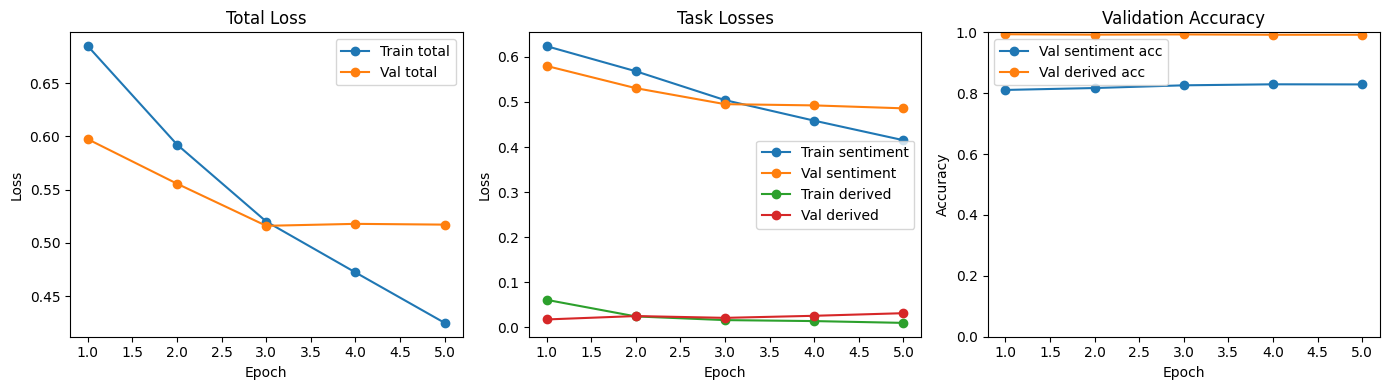

In [40]:
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR


def compute_macro_f1(preds: list[int], targets: list[int], num_classes: int) -> float:
    # computes macro f1 without extra libraries.
    f1_scores = []
    for cls in range(num_classes):
        tp = sum((p == cls and t == cls) for p, t in zip(preds, targets))
        fp = sum((p == cls and t != cls) for p, t in zip(preds, targets))
        fn = sum((p != cls and t == cls) for p, t in zip(preds, targets))

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = (2 * precision * recall) / (precision + recall + 1e-9)
        f1_scores.append(f1)

    return float(sum(f1_scores) / len(f1_scores))


def compute_combined_loss(
    sent_logits: torch.Tensor,
    der_logits: torch.Tensor,
    sent_targets: torch.Tensor,
    der_targets: torch.Tensor,
    criterion: nn.Module,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # adds both task losses with equal weight.
    sent_loss = criterion(sent_logits, sent_targets)
    der_loss = criterion(der_logits, der_targets)
    total_loss = sent_loss + der_loss
    return total_loss, sent_loss.detach(), der_loss.detach()


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
) -> dict[str, float]:
    # trains for one epoch and returns average losses.
    model.train()
    total_samples = 0
    total_loss_sum, sent_loss_sum, der_loss_sum = 0.0, 0.0, 0.0

    for input_ids, attention_mask, sent_targets, der_targets in dataloader:
        optimizer.zero_grad()
        sent_logits, der_logits, _ = model(input_ids, attention_mask)
        total_loss, sent_loss, der_loss = compute_combined_loss(
            sent_logits, der_logits, sent_targets, der_targets, criterion
        )
        total_loss.backward()
        optimizer.step()

        batch_size = input_ids.size(0)
        total_samples += batch_size
        total_loss_sum += total_loss.item() * batch_size
        sent_loss_sum += sent_loss.item() * batch_size
        der_loss_sum += der_loss.item() * batch_size

    return {
        "total_loss": total_loss_sum / total_samples,
        "sent_loss": sent_loss_sum / total_samples,
        "der_loss": der_loss_sum / total_samples,
    }


@torch.no_grad()
def evaluate_model(model: nn.Module, dataloader: DataLoader, criterion: nn.Module) -> dict[str, float]:
    # evaluates losses and metrics for both tasks.
    model.eval()
    total_samples = 0
    total_loss_sum, sent_loss_sum, der_loss_sum = 0.0, 0.0, 0.0

    sent_preds_all, sent_targets_all = [], []
    der_preds_all, der_targets_all = [], []

    for input_ids, attention_mask, sent_targets, der_targets in dataloader:
        sent_logits, der_logits, _ = model(input_ids, attention_mask)
        total_loss, sent_loss, der_loss = compute_combined_loss(
            sent_logits, der_logits, sent_targets, der_targets, criterion
        )

        sent_preds = torch.argmax(sent_logits, dim=1)
        der_preds = torch.argmax(der_logits, dim=1)

        batch_size = input_ids.size(0)
        total_samples += batch_size
        total_loss_sum += total_loss.item() * batch_size
        sent_loss_sum += sent_loss.item() * batch_size
        der_loss_sum += der_loss.item() * batch_size

        sent_preds_all.extend(sent_preds.tolist())
        sent_targets_all.extend(sent_targets.tolist())
        der_preds_all.extend(der_preds.tolist())
        der_targets_all.extend(der_targets.tolist())

    sent_acc = sum(int(p == t) for p, t in zip(sent_preds_all, sent_targets_all)) / len(sent_targets_all)
    der_acc = sum(int(p == t) for p, t in zip(der_preds_all, der_targets_all)) / len(der_targets_all)

    return {
        "total_loss": total_loss_sum / total_samples,
        "sent_loss": sent_loss_sum / total_samples,
        "der_loss": der_loss_sum / total_samples,
        "sent_acc": sent_acc,
        "der_acc": der_acc,
        "sent_macro_f1": compute_macro_f1(sent_preds_all, sent_targets_all, num_classes=3),
        "der_macro_f1": compute_macro_f1(der_preds_all, der_targets_all, num_classes=3),
    }


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 5,
    lr: float = 2e-3,
) -> dict[str, list[float]]:
    # runs full training and keeps history for plots.
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=2, gamma=0.8)

    history = {
        "train_total_loss": [],
        "train_sent_loss": [],
        "train_der_loss": [],
        "val_total_loss": [],
        "val_sent_loss": [],
        "val_der_loss": [],
        "val_sent_acc": [],
        "val_der_acc": [],
        "val_sent_macro_f1": [],
        "val_der_macro_f1": [],
        "lr": [],
    }

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics = evaluate_model(model, val_loader, criterion)
        scheduler.step()

        history["train_total_loss"].append(train_metrics["total_loss"])
        history["train_sent_loss"].append(train_metrics["sent_loss"])
        history["train_der_loss"].append(train_metrics["der_loss"])
        history["val_total_loss"].append(val_metrics["total_loss"])
        history["val_sent_loss"].append(val_metrics["sent_loss"])
        history["val_der_loss"].append(val_metrics["der_loss"])
        history["val_sent_acc"].append(val_metrics["sent_acc"])
        history["val_der_acc"].append(val_metrics["der_acc"])
        history["val_sent_macro_f1"].append(val_metrics["sent_macro_f1"])
        history["val_der_macro_f1"].append(val_metrics["der_macro_f1"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_metrics['total_loss']:.4f} | "
            f"val_loss={val_metrics['total_loss']:.4f} | "
            f"val_sent_acc={val_metrics['sent_acc']:.4f} | "
            f"val_der_acc={val_metrics['der_acc']:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

    return history


def plot_training_curves(history: dict[str, list[float]]) -> None:
    # shows training and validation loss curves clearly.
    epochs = list(range(1, len(history["train_total_loss"]) + 1))

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_total_loss"], marker="o", label="Train total")
    plt.plot(epochs, history["val_total_loss"], marker="o", label="Val total")
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_sent_loss"], marker="o", label="Train sentiment")
    plt.plot(epochs, history["val_sent_loss"], marker="o", label="Val sentiment")
    plt.plot(epochs, history["train_der_loss"], marker="o", label="Train derived")
    plt.plot(epochs, history["val_der_loss"], marker="o", label="Val derived")
    plt.title("Task Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_sent_acc"], marker="o", label="Val sentiment acc")
    plt.plot(epochs, history["val_der_acc"], marker="o", label="Val derived acc")
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()

    plt.tight_layout()
    plt.show()


history = train_model(
    model=multi_task_model,
    train_loader=loaders_mt["train"],
    val_loader=loaders_mt["val"],
    epochs=5,
    lr=2e-3,
)

plot_training_curves(history)

##   evaluate final metrics on validation and test data

In [43]:
criterion_eval = nn.CrossEntropyLoss()
val_metrics = evaluate_model(multi_task_model, loaders_mt["val"], criterion_eval)
test_metrics = evaluate_model(multi_task_model, loaders_mt["test"], criterion_eval)

print("Validation metrics:")
for key, value in val_metrics.items():
    print(f"  {key}: {value:.4f}")

print("\nTest metrics:")
for key, value in test_metrics.items():
    print(f"  {key}: {value:.4f}")

Validation metrics:
  total_loss: 0.5172
  sent_loss: 0.4859
  der_loss: 0.0313
  sent_acc: 0.8289
  der_acc: 0.9920
  sent_macro_f1: 0.5222
  der_macro_f1: 0.9919

Test metrics:
  total_loss: 0.5208
  sent_loss: 0.4955
  der_loss: 0.0252
  sent_acc: 0.8181
  der_acc: 0.9933
  sent_macro_f1: 0.5088
  der_macro_f1: 0.9933


##   extract and save fixed size review embeddings

In [44]:
@torch.no_grad()
def collect_embeddings(
    model: nn.Module,
    dataloader: DataLoader,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # collects pooled review vectors and labels from a split.
    model.eval()
    all_embeddings, all_sentiment, all_derived = [], [], []

    for input_ids, attention_mask, sent_targets, der_targets in dataloader:
        _, _, pooled = model(input_ids, attention_mask)
        all_embeddings.append(pooled.cpu())
        all_sentiment.append(sent_targets.cpu())
        all_derived.append(der_targets.cpu())

    return (
        torch.cat(all_embeddings, dim=0),
        torch.cat(all_sentiment, dim=0),
        torch.cat(all_derived, dim=0),
    )


def save_split_embeddings(split_name: str, model: nn.Module, dataloader: DataLoader, path: str) -> None:
    # saves embeddings and labels in one file for later retrieval.
    embeddings, sentiment_labels, derived_labels = collect_embeddings(model, dataloader)
    payload = {
        "embeddings": embeddings,
        "sentiment_label": sentiment_labels,
        "derived_label": derived_labels,
    }
    torch.save(payload, path)
    print(f"Saved {split_name} embeddings: {embeddings.shape} -> {path}")


save_split_embeddings("train", multi_task_model, loaders_mt["train"], "embeddings_train.pt")
save_split_embeddings("val", multi_task_model, loaders_mt["val"], "embeddings_val.pt")
save_split_embeddings("test", multi_task_model, loaders_mt["test"], "embeddings_test.pt")

Saved train embeddings: torch.Size([25200, 128]) -> embeddings_train.pt
Saved val embeddings: torch.Size([5400, 128]) -> embeddings_val.pt
Saved test embeddings: torch.Size([5400, 128]) -> embeddings_test.pt


##   part b

##   retrieval module with stored index and configurable top k

In [45]:
import os
import torch.nn.functional as F

RETRIEVAL_K = 5
RETRIEVAL_CHUNK_SIZE = 256


def build_training_index(
    model: nn.Module,
    train_split_tensors: dict[str, torch.Tensor],
    train_df: pd.DataFrame,
    batch_size: int,
) -> dict[str, object]:
    # builds an ordered cosine-search index from training encoder outputs.
    ordered_loader = build_multitask_dataloader(train_split_tensors, batch_size=batch_size, shuffle=False)
    embeddings, sentiment_labels, derived_labels = collect_embeddings(model, ordered_loader)

    index_vectors = F.normalize(embeddings.float(), p=2, dim=1).contiguous()
    index_payload = {
        "vectors": index_vectors,
        "texts": train_df["review_text"].tolist(),
        "sentiment_label": sentiment_labels.long().contiguous(),
        "derived_label": derived_labels.long().contiguous(),
    }
    return index_payload


def save_index_payload(index_payload: dict[str, object], path: str) -> None:
    # saves the retrieval index so it can be reused at inference time.
    torch.save(index_payload, path)
    print(f"Saved retrieval index -> {path}")


os.makedirs("results", exist_ok=True)

retrieval_index = build_training_index(
    model=multi_task_model,
    train_split_tensors=preprocessed_mt["train"],
    train_df=splits["train"],
    batch_size=BATCH_SIZE,
)

save_index_payload(retrieval_index, "results/retrieval_index.pt")

print("Index vector shape:", retrieval_index["vectors"].shape)
print("Indexed training reviews:", len(retrieval_index["texts"]))

Saved retrieval index -> results/retrieval_index.pt
Index vector shape: torch.Size([25200, 128])
Indexed training reviews: 25200


##   build test queries then retrieve and rank top k similar training reviews

k is configurable by RETRIEVAL_K and we use k = 5 as a balance between relevance and context size.

In [ ]:
@torch.no_grad()
def build_query_vectors(model: nn.Module, test_loader: DataLoader) -> torch.Tensor:
    # builds normalized query vectors from encoder outputs for each test review.
    embeddings, _, _ = collect_embeddings(model, test_loader)
    query_vectors = F.normalize(embeddings.float(), p=2, dim=1).contiguous()
    return query_vectors


def retrieve_top_k_chunked(
    query_vectors: torch.Tensor,
    index_vectors: torch.Tensor,
    k: int,
    chunk_size: int = 256,
) -> tuple[torch.Tensor, torch.Tensor]:
    # retrieves top-k neighbors in chunks for memory-safe inference.
    all_scores, all_indices = [], []
    index_vectors_t = index_vectors.T.contiguous()

    for start in range(0, query_vectors.size(0), chunk_size):
        end = min(start + chunk_size, query_vectors.size(0))
        chunk = query_vectors[start:end]
        similarity = torch.matmul(chunk, index_vectors_t)
        top_scores, top_indices = torch.topk(similarity, k=min(k, index_vectors.size(0)), dim=1)
        all_scores.append(top_scores)
        all_indices.append(top_indices)

    return torch.cat(all_scores, dim=0), torch.cat(all_indices, dim=0)


def compute_label_match_rates(
    top_indices: torch.Tensor,
    query_labels: torch.Tensor,
    index_labels: torch.Tensor,
) -> tuple[float, float]:
    # computes top-1 and hit@k label match rates as retrieval quality signals.
    retrieved_labels = index_labels[top_indices]
    top1 = (retrieved_labels[:, 0] == query_labels).float().mean().item()
    hitk = (retrieved_labels == query_labels.unsqueeze(1)).any(dim=1).float().mean().item()
    return top1, hitk


test_loader_ordered = build_multitask_dataloader(preprocessed_mt["test"], batch_size=BATCH_SIZE, shuffle=False)
query_vectors = build_query_vectors(multi_task_model, test_loader_ordered)

retrieved_scores, retrieved_indices = retrieve_top_k_chunked(
    query_vectors=query_vectors,
    index_vectors=retrieval_index["vectors"],
    k=RETRIEVAL_K,
    chunk_size=RETRIEVAL_CHUNK_SIZE,
)

sent_top1, sent_topk = compute_label_match_rates(
    retrieved_indices,
    preprocessed_mt["test"]["sentiment_label"],
    retrieval_index["sentiment_label"],
)

der_top1, der_topk = compute_label_match_rates(
    retrieved_indices,
    preprocessed_mt["test"]["derived_label"],
    retrieval_index["derived_label"],
)

print(f"Retrieval uses cosine similarity with k = {RETRIEVAL_K}")
print(f"Top-1 sentiment match rate: {sent_top1:.4f}")
print(f"Top-k sentiment match rate: {sent_topk:.4f}")
print(f"Top-1 derived-feature match rate: {der_top1:.4f}")
print(f"Top-k derived-feature match rate: {der_topk:.4f}")

Retrieval uses cosine similarity with k = 5
Top-1 sentiment match rate: 0.7687
Top-k sentiment match rate: 0.7685
Top-1 derived-feature match rate: 0.9930
Top-k derived-feature match rate: 0.9935


##   inspect retrieval quality and build decoder ready context for part c

In [47]:
SENTIMENT_TEXT = {0: "Negative", 1: "Neutral", 2: "Positive"}
DERIVED_TEXT = {0: "Short", 1: "Medium", 2: "Long"}


@torch.no_grad()
def predict_labels_for_split(model: nn.Module, dataloader: DataLoader) -> tuple[torch.Tensor, torch.Tensor]:
    # predicts both task labels for one split in order.
    model.eval()
    sent_preds_all, der_preds_all = [], []

    for input_ids, attention_mask, _, _ in dataloader:
        sent_logits, der_logits, _ = model(input_ids, attention_mask)
        sent_preds_all.append(torch.argmax(sent_logits, dim=1).cpu())
        der_preds_all.append(torch.argmax(der_logits, dim=1).cpu())

    return torch.cat(sent_preds_all), torch.cat(der_preds_all)


def shorten_text(text: str, max_chars: int = 170) -> str:
    # shortens text for compact readable console output.
    text = " ".join(text.split())
    return text if len(text) <= max_chars else text[: max_chars - 3] + "..."


def build_decoder_prompt(
    review_text: str,
    pred_sentiment: int,
    pred_derived: int,
    retrieved_texts: list[str],
) -> str:
    # creates one structured prompt that passes retrieval context to the decoder.
    retrieved_block = "\n".join([f"- {txt}" for txt in retrieved_texts])
    prompt = (
        f"[REVIEW] {review_text}\n"
        f"[PREDICTED_SENTIMENT] {SENTIMENT_TEXT[pred_sentiment]}\n"
        f"[PREDICTED_DERIVED] {DERIVED_TEXT[pred_derived]}\n"
        f"[RETRIEVED_CONTEXT]\n{retrieved_block}\n"
        f"[EXPLANATION]"
    )
    return prompt


def export_retrieval_outputs(
    test_texts: list[str],
    top_indices: torch.Tensor,
    top_scores: torch.Tensor,
    index_payload: dict[str, object],
    pred_sent: torch.Tensor,
    pred_der: torch.Tensor,
    out_table_path: str,
    out_prompt_path: str,
) -> None:
    # saves ranked retrieval table and decoder prompts for downstream use.
    rows, prompts = [], []

    for qid, query_text in enumerate(test_texts):
        retrieved_texts = []

        for rank in range(top_indices.size(1)):
            idx = int(top_indices[qid, rank].item())
            score = float(top_scores[qid, rank].item())
            retrieved_text = index_payload["texts"][idx]
            retrieved_texts.append(retrieved_text)
            rows.append(
                {
                    "query_id": qid,
                    "rank": rank + 1,
                    "score": score,
                    "query_text": query_text,
                    "retrieved_text": retrieved_text,
                    "retrieved_sentiment": int(index_payload["sentiment_label"][idx].item()),
                    "retrieved_derived": int(index_payload["derived_label"][idx].item()),
                }
            )

        prompts.append(
            {
                "query_id": qid,
                "predicted_sentiment": int(pred_sent[qid].item()),
                "predicted_derived": int(pred_der[qid].item()),
                "decoder_prompt": build_decoder_prompt(
                    review_text=query_text,
                    pred_sentiment=int(pred_sent[qid].item()),
                    pred_derived=int(pred_der[qid].item()),
                    retrieved_texts=[shorten_text(txt, max_chars=180) for txt in retrieved_texts],
                ),
            }
        )

    pd.DataFrame(rows).to_csv(out_table_path, index=False)
    pd.DataFrame(prompts).to_csv(out_prompt_path, index=False)
    print(f"Saved ranked retrieval table -> {out_table_path}")
    print(f"Saved decoder-ready prompts -> {out_prompt_path}")


test_texts = splits["test"]["review_text"].tolist()
pred_sentiment_test, pred_derived_test = predict_labels_for_split(multi_task_model, test_loader_ordered)

export_retrieval_outputs(
    test_texts=test_texts,
    top_indices=retrieved_indices,
    top_scores=retrieved_scores,
    index_payload=retrieval_index,
    pred_sent=pred_sentiment_test,
    pred_der=pred_derived_test,
    out_table_path="results/retrieval_topk_results.csv",
    out_prompt_path="results/decoder_inputs_partb.csv",
)

sample_query_ids = [0, 17, 111]
for qid in sample_query_ids:
    print("\n" + "=" * 80)
    print(f"Query {qid} | Pred Sentiment: {SENTIMENT_TEXT[int(pred_sentiment_test[qid].item())]} | Pred Feature: {DERIVED_TEXT[int(pred_derived_test[qid].item())]}")
    print("Query text:", shorten_text(test_texts[qid], max_chars=220))

    for rank in range(RETRIEVAL_K):
        ridx = int(retrieved_indices[qid, rank].item())
        score = float(retrieved_scores[qid, rank].item())
        print(f"  Top-{rank + 1} | score={score:.4f} | text={shorten_text(retrieval_index['texts'][ridx], max_chars=180)}")

    prompt_preview = build_decoder_prompt(
        review_text=shorten_text(test_texts[qid], max_chars=220),
        pred_sentiment=int(pred_sentiment_test[qid].item()),
        pred_derived=int(pred_derived_test[qid].item()),
        retrieved_texts=[shorten_text(retrieval_index["texts"][int(retrieved_indices[qid, r].item())], max_chars=120) for r in range(RETRIEVAL_K)],
    )
    print("\nDecoder prompt preview:")
    print(prompt_preview)


Saved ranked retrieval table -> results/retrieval_topk_results.csv
Saved decoder-ready prompts -> results/decoder_inputs_partb.csv

Query 0 | Pred Sentiment: Positive | Pred Feature: Medium
Query text: Very easy to use and handy cases for you key chain or to stick in your pocket. You could put it on a nail by your front door or your door in case of an intruder. I keep one on me at all times and I am carefully placin...
  Top-1 | score=0.9936 | text=i say good quality, not great... It really only charges to about 80%, but then again, it is less than half the price of the LP-E6 by Canon. It charges consistently and always us...
  Top-2 | score=0.9920 | text=I have several of the Columbia Bahama II's and really like them. I purchased this style mainly to wear for work(I.T. Business). This shirt is a bit &#34;stronger/stiffer&#34; th...
  Top-3 | score=0.9917 | text=Bought a couple of Iron Mind Grips and love them, but cannot afford to buy all of the sizes in Iron Mind.This was a great alt

# Part C

##   load retrieval outputs and prepare decoder inputs

In [2]:
import math
import os
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cpu")

DECODER_K = 5
DECODER_MAX_LEN = 128
DECODER_BATCH_SIZE = 32
DECODER_EPOCHS = 2
DECODER_LR = 2e-3

MAX_TRAIN_SAMPLES = 12000
MAX_VAL_SAMPLES = 3000

TRAIN_PATH = "train.csv"
VAL_PATH = "val.csv"
TEST_PATH = "test.csv"
INDEX_PATH = "results/retrieval_index.pt"
EMB_TRAIN_PATH = "embeddings_train.pt"
EMB_VAL_PATH = "embeddings_val.pt"
EMB_TEST_PATH = "embeddings_test.pt"
DECODER_INPUTS_TEST_PATH = "results/decoder_inputs_partb.csv"

SENTIMENT_TEXT = {0: "Negative", 1: "Neutral", 2: "Positive"}
DERIVED_TEXT = {0: "Short", 1: "Medium", 2: "Long"}


def rating_to_sentiment(rating: int) -> int:
    #    maps ratings into the required 3 sentiment classes.
    if rating <= 2:
        return 0
    if rating == 3:
        return 1
    return 2


def clean_text(text: str) -> str:
    #    normalizes text for consistent tokenization.
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def tokenize(text: str) -> list[str]:
    #    splits text into word-like tokens.
    return re.findall(r"[a-z0-9']+", clean_text(text))


def review_length(text: str) -> int:
    #    counts tokens in a review after cleaning.
    return len(tokenize(text))


def add_length3_labels(df: pd.DataFrame, q1: int, q2: int) -> pd.Series:
    #    assigns short/medium/long labels based on train quantiles.
    lengths = df["review_text"].apply(review_length)
    labels = np.where(lengths < q1, 0, np.where(lengths < q2, 1, 2)).astype(int)
    return pd.Series(labels, index=df.index)


def shorten_text(text: str, max_chars: int = 180) -> str:
    #    shortens text for compact prompts.
    text = " ".join(str(text).split())
    return text if len(text) <= max_chars else text[: max_chars - 3] + "..."


def build_decoder_prompt(
    review_text: str,
    pred_sentiment: int,
    pred_derived: int,
    retrieved_texts: list[str],
) -> str:
    #    creates one structured prompt that passes retrieval context to the decoder.
    retrieved_block = "\n".join([f"- {txt}" for txt in retrieved_texts])
    prompt = (
        f"[REVIEW] {review_text}\n"
        f"[PREDICTED_SENTIMENT] {SENTIMENT_TEXT[pred_sentiment]}\n"
        f"[PREDICTED_DERIVED] {DERIVED_TEXT[pred_derived]}\n"
        f"[RETRIEVED_CONTEXT]\n{retrieved_block}\n"
        f"[EXPLANATION]"
)
    return prompt


def load_embeddings(path: str) -> torch.Tensor:
    #    loads pooled embeddings from disk.
    payload = torch.load(path, map_location="cpu")
    return payload["embeddings"].float()


def retrieve_top_k_chunked(
    query_vectors: torch.Tensor,
    index_vectors: torch.Tensor,
    k: int,
    chunk_size: int = 256,
    exclude_self: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    #    retrieves top-k neighbors in chunks for memory-safe inference.
    all_scores, all_indices = [], []
    index_vectors_t = index_vectors.T.contiguous()

    for start in range(0, query_vectors.size(0), chunk_size):
        end = min(start + chunk_size, query_vectors.size(0))
        chunk = query_vectors[start:end]
        similarity = torch.matmul(chunk, index_vectors_t)

        if exclude_self:
            row_ids = torch.arange(end - start)
            col_ids = torch.arange(start, end)
            similarity[row_ids, col_ids] = -1e9

        top_scores, top_indices = torch.topk(similarity, k=min(k, index_vectors.size(0)), dim=1)
        all_scores.append(top_scores)
        all_indices.append(top_indices)

    return torch.cat(all_scores, dim=0), torch.cat(all_indices, dim=0)


def extract_keywords(text: str, top_n: int = 3) -> list[str]:
    #    pulls simple keywords for heuristic explanations.
    stopwords = {"the", "a", "an", "and", "or", "to", "of", "in", "is", "it", "this", "that", "for", "on", "with", "was", "were", "are", "be", "as", "at", "but", "by", "from", "i", "we", "you", "they", "my", "our", "their"}
    tokens = [t for t in tokenize(text) if t not in stopwords and len(t) > 2]
    if not tokens:
        return ["details"]
    counts = Counter(tokens)
    return [w for w, _ in counts.most_common(top_n)]


def build_explanation(
    review_text: str,
    sentiment_label: int,
    derived_label: int,
    retrieved_texts: list[str],
) -> str:
    #    creates a short, grounded explanation target for language modeling.
    keywords = extract_keywords(review_text, top_n=3)
    retrieved_keywords = extract_keywords(" ".join(retrieved_texts), top_n=2)
    sent_text = SENTIMENT_TEXT[sentiment_label].lower()
    length_text = DERIVED_TEXT[derived_label].lower()

    sentence1 = (
        f"The review is {sent_text} because it mentions {', '.join(keywords)} and feels {length_text}."
    )
    sentence2 = (
        f"Similar reviews also highlight {', '.join(retrieved_keywords)}."
    )
    return sentence1 + " " + sentence2


train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in (train_df, val_df, test_df):
    df["rating"] = df["rating"].astype(int)
    df["sentiment_label"] = df["rating"].apply(rating_to_sentiment)

train_lengths = train_df["review_text"].apply(review_length)
q1_len = int(train_lengths.quantile(1 / 3))
q2_len = int(train_lengths.quantile(2 / 3))
if q2_len <= q1_len:
    q2_len = q1_len + 1

train_df["length3_label"] = add_length3_labels(train_df, q1_len, q2_len)
val_df["length3_label"] = add_length3_labels(val_df, q1_len, q2_len)
test_df["length3_label"] = add_length3_labels(test_df, q1_len, q2_len)

retrieval_index = torch.load(INDEX_PATH, map_location="cpu")
index_vectors = retrieval_index["vectors"].float()
index_texts = retrieval_index["texts"]

emb_train = F.normalize(load_embeddings(EMB_TRAIN_PATH), p=2, dim=1)
emb_val = F.normalize(load_embeddings(EMB_VAL_PATH), p=2, dim=1)
emb_test = F.normalize(load_embeddings(EMB_TEST_PATH), p=2, dim=1)

train_scores, train_indices = retrieve_top_k_chunked(
    emb_train, index_vectors, k=DECODER_K, chunk_size=256, exclude_self=True
 )
val_scores, val_indices = retrieve_top_k_chunked(
    emb_val, index_vectors, k=DECODER_K, chunk_size=256, exclude_self=False
 )
test_scores, test_indices = retrieve_top_k_chunked(
    emb_test, index_vectors, k=DECODER_K, chunk_size=256, exclude_self=False
 )

def build_records_from_indices(
    df: pd.DataFrame,
    indices: torch.Tensor,
    use_predicted_labels: bool = False,
    predicted_labels: pd.DataFrame | None = None,
) -> list[dict[str, str]]:
    #    builds prompt + explanation records for decoder training.
    records = []
    for qid, row in df.reset_index(drop=True).iterrows():
        retrieved_texts = [shorten_text(index_texts[int(idx)]) for idx in indices[qid]]
        if use_predicted_labels and predicted_labels is not None:
            sent_label = int(predicted_labels.loc[qid, "predicted_sentiment"])
            der_label = int(predicted_labels.loc[qid, "predicted_derived"])
        else:
            sent_label = int(row["sentiment_label"])
            der_label = int(row["length3_label"])

        prompt = build_decoder_prompt(
            review_text=shorten_text(row["review_text"], max_chars=220),
            pred_sentiment=sent_label,
            pred_derived=der_label,
            retrieved_texts=retrieved_texts,
        )
        explanation = build_explanation(
            review_text=row["review_text"],
            sentiment_label=sent_label,
            derived_label=der_label,
            retrieved_texts=retrieved_texts,
        )
        records.append({"prompt": prompt, "explanation": explanation, "review_text": row["review_text"]})
    return records


decoder_inputs_test = pd.read_csv(DECODER_INPUTS_TEST_PATH)
decoder_inputs_test = decoder_inputs_test.sort_values("query_id").reset_index(drop=True)

train_records = build_records_from_indices(train_df, train_indices)
val_records = build_records_from_indices(val_df, val_indices)
test_records = build_records_from_indices(
    test_df,
    test_indices,
    use_predicted_labels=True,
    predicted_labels=decoder_inputs_test[["predicted_sentiment", "predicted_derived"]],
)

if MAX_TRAIN_SAMPLES is not None and len(train_records) > MAX_TRAIN_SAMPLES:
    random.shuffle(train_records)
    train_records = train_records[:MAX_TRAIN_SAMPLES]

if MAX_VAL_SAMPLES is not None and len(val_records) > MAX_VAL_SAMPLES:
    random.shuffle(val_records)
    val_records = val_records[:MAX_VAL_SAMPLES]

print(f"Train records: {len(train_records)} | Val records: {len(val_records)} | Test records: {len(test_records)}")

Train records: 12000 | Val records: 3000 | Test records: 5400


##   build decoder vocabulary and tensors

In [3]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
BOS_TOKEN = "<BOS>"
EOS_TOKEN = "<EOS>"

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3


def build_decoder_vocab(records: list[dict[str, str]], min_freq: int = 2) -> tuple[dict[str, int], dict[int, str]]:
    #    builds a decoder vocab from training prompts and explanations only.
    counter = Counter()
    for item in records:
        counter.update(tokenize(item["prompt"]))
        counter.update(tokenize(item["explanation"]))

    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX, BOS_TOKEN: BOS_IDX, EOS_TOKEN: EOS_IDX}
    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)

    itos = {idx: tok for tok, idx in vocab.items()}
    return vocab, itos


def tokens_to_indices(tokens: list[str], vocab: dict[str, int]) -> list[int]:
    #    maps tokens into ids using decoder vocab.
    return [vocab.get(tok, UNK_IDX) for tok in tokens]


def build_lm_sample(
    prompt: str,
    explanation: str,
    vocab: dict[str, int],
    max_len: int,
) -> tuple[list[int], list[int], list[int]]:
    #    builds input ids and labels for decoder-only language modeling.
    prompt_tokens = tokenize(prompt)
    expl_tokens = tokenize(explanation)

    max_prompt_len = max_len - 1 - len(expl_tokens)
    if max_prompt_len < 1:
        expl_tokens = expl_tokens[: max_len - 2]
        max_prompt_len = 1
    prompt_tokens = prompt_tokens[:max_prompt_len]

    input_tokens = [BOS_TOKEN] + prompt_tokens + expl_tokens + [EOS_TOKEN]
    input_ids = tokens_to_indices(input_tokens, vocab)

    prompt_len = 1 + len(prompt_tokens)
    labels = [-100] * prompt_len
    labels += tokens_to_indices(expl_tokens + [EOS_TOKEN], vocab)

    if len(input_ids) < max_len:
        pad_count = max_len - len(input_ids)
        input_ids += [PAD_IDX] * pad_count
        labels += [-100] * pad_count
        attention_mask = [1] * (max_len - pad_count) + [0] * pad_count
    else:
        input_ids = input_ids[:max_len]
        labels = labels[:max_len]
        attention_mask = [1] * max_len

    return input_ids, attention_mask, labels


def build_dataset(
    records: list[dict[str, str]],
    vocab: dict[str, int],
    max_len: int,
) -> dict[str, torch.Tensor]:
    #    creates tensor datasets for decoder training and evaluation.
    input_ids, attention_masks, labels = [], [], []
    for item in records:
        ids, mask, lbls = build_lm_sample(item["prompt"], item["explanation"], vocab, max_len)
        input_ids.append(ids)
        attention_masks.append(mask)
        labels.append(lbls)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


decoder_vocab, decoder_itos = build_decoder_vocab(train_records, min_freq=2)
print(f"Decoder vocab size: {len(decoder_vocab)}")

train_ds = build_dataset(train_records, decoder_vocab, DECODER_MAX_LEN)
val_ds = build_dataset(val_records, decoder_vocab, DECODER_MAX_LEN)
test_ds = build_dataset(test_records, decoder_vocab, DECODER_MAX_LEN)

def build_decoder_loader(split_dict: dict[str, torch.Tensor], batch_size: int, shuffle: bool) -> DataLoader:
    #    wraps decoder tensors into a dataloader.
    ds = TensorDataset(split_dict["input_ids"], split_dict["attention_mask"], split_dict["labels"])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

decoder_loaders = {
    "train": build_decoder_loader(train_ds, DECODER_BATCH_SIZE, shuffle=True),
    "val": build_decoder_loader(val_ds, DECODER_BATCH_SIZE, shuffle=False),
    "test": build_decoder_loader(test_ds, DECODER_BATCH_SIZE, shuffle=False),
}

Decoder vocab size: 22321


##   decoder-only transformer with causal self-attention

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        #    precomputes sinusoidal positions once for fast reuse.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #    adds position information to token embeddings.
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class DecoderSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        #    builds masked self-attention for autoregressive decoding.
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        #    reshapes vectors into independent attention heads.
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        #    merges all heads back into one vector per token.
        batch_size, _, seq_len, _ = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        #    applies causal and padding masks so no future tokens are seen.
        q = self._split_heads(self.q_proj(x))
        k = self._split_heads(self.k_proj(x))
        v = self._split_heads(self.v_proj(x))

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        seq_len = scores.size(-1)
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=scores.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        if attention_mask is not None:
            pad_mask = attention_mask.unsqueeze(1).unsqueeze(2).bool()
            full_mask = pad_mask & causal_mask
        else:
            full_mask = causal_mask

        scores = scores.masked_fill(~full_mask, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)

        attn_weights = attn_weights * full_mask.float()
        attn_weights = attn_weights / attn_weights.sum(dim=-1, keepdim=True).clamp_min(1e-9)
        attn_weights = self.dropout(attn_weights)

        context = torch.matmul(attn_weights, v)
        context = self._combine_heads(context)
        return self.out_proj(context)


class DecoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        #    creates one decoder block with masked self-attention and feed-forward parts.
        self.self_attn = DecoderSelfAttention(d_model, num_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        #    applies residual connections and layer normalization in order.
        attn_out = self.self_attn(x, attention_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x


class DecoderTransformer(nn.Module):
    def __init__(
    self,
    vocab_size: int,
    d_model: int = 128,
    num_heads: int = 4,
    ff_dim: int = 256,
    num_layers: int = 2,
    max_len: int = 196,
    dropout: float = 0.1,
):
        super().__init__()
        #    assembles token embedding, positional encoding, and decoder stack.
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.position_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [DecoderBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        )
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        #    returns logits for each token position.
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, attention_mask)
        return self.lm_head(x)


def compute_lm_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    criterion: nn.Module,
) -> tuple[torch.Tensor, int]:
    #    computes total loss and token count for perplexity.
    vocab_size = logits.size(-1)
    loss = criterion(logits.view(-1, vocab_size), labels.view(-1))
    token_count = int((labels != -100).sum().item())
    return loss, token_count


def train_decoder(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
) -> dict[str, float]:
    #    trains the decoder for one epoch.
    model.train()
    total_loss, total_tokens = 0.0, 0
    for input_ids, attention_mask, labels in loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss, token_count = compute_lm_loss(logits, labels, criterion)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_tokens += token_count

    avg_loss = total_loss / max(total_tokens, 1)
    return {"loss": avg_loss, "ppl": float(math.exp(avg_loss))}


@torch.no_grad()
def eval_decoder(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict[str, float]:
    #    evaluates decoder loss and perplexity.
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for input_ids, attention_mask, labels in loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = model(input_ids, attention_mask)
        loss, token_count = compute_lm_loss(logits, labels, criterion)
        total_loss += loss.item()
        total_tokens += token_count

    avg_loss = total_loss / max(total_tokens, 1)
    return {"loss": avg_loss, "ppl": float(math.exp(avg_loss))}


def ids_to_text(ids: list[int], itos: dict[int, str]) -> str:
    #    converts token ids back to a readable string.
    words = [itos.get(i, UNK_TOKEN) for i in ids]
    words = [w for w in words if w not in (PAD_TOKEN, BOS_TOKEN, EOS_TOKEN)]
    return " ".join(words).strip()


@torch.no_grad()
def generate_explanation(
    model: nn.Module,
    prompt: str,
    vocab: dict[str, int],
    itos: dict[int, str],
    max_len: int,
    min_new_tokens: int = 8,
    top_k: int = 20,
) -> str:
    #    autoregressively generates one explanation with light sampling.
    model.eval()
    prompt_tokens = tokenize(prompt)
    max_prompt_len = max_len - min_new_tokens - 1
    prompt_tokens = prompt_tokens[: max(1, max_prompt_len)]
    input_tokens = [BOS_TOKEN] + prompt_tokens
    prompt_len = len(input_tokens)
    input_ids = tokens_to_indices(input_tokens, vocab)
    attention_mask = [1] * len(input_ids)

    for step in range(max_len - len(input_ids)):
        input_tensor = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)
        mask_tensor = torch.tensor([attention_mask], dtype=torch.long, device=DEVICE)
        logits = model(input_tensor, mask_tensor)[0, -1]
        topk_vals, topk_idx = torch.topk(logits, k=min(top_k, logits.size(0)))
        probs = torch.softmax(topk_vals, dim=-1)

        if step < min_new_tokens:
            eos_mask = topk_idx == EOS_IDX
            if eos_mask.any():
                probs = probs.masked_fill(eos_mask, 0.0)
                probs = probs / probs.sum().clamp_min(1e-9)

        next_id = int(topk_idx[torch.multinomial(probs, 1)].item())
        input_ids.append(next_id)
        attention_mask.append(1)
        if next_id == EOS_IDX and step >= min_new_tokens:
            break

    gen_ids = input_ids[prompt_len:]
    return ids_to_text(gen_ids, itos)

##   train full rag decoder and baseline (no retrieval)

In [5]:
def build_baseline_records(records: list[dict[str, str]]) -> list[dict[str, str]]:
    #    removes retrieved context for the ablation baseline.
    baseline_records = []
    for item in records:
        prompt_lines = item["prompt"].split("[RETRIEVED_CONTEXT]")
        prompt = prompt_lines[0] + "[RETRIEVED_CONTEXT]\n- none\n[EXPLANATION]"
        baseline_records.append({"prompt": prompt, "explanation": item["explanation"], "review_text": item["review_text"]})
    return baseline_records


baseline_train_records = build_baseline_records(train_records)
baseline_val_records = build_baseline_records(val_records)
baseline_test_records = build_baseline_records(test_records)

baseline_train_ds = build_dataset(baseline_train_records, decoder_vocab, DECODER_MAX_LEN)
baseline_val_ds = build_dataset(baseline_val_records, decoder_vocab, DECODER_MAX_LEN)
baseline_test_ds = build_dataset(baseline_test_records, decoder_vocab, DECODER_MAX_LEN)

baseline_loaders = {
    "train": build_decoder_loader(baseline_train_ds, DECODER_BATCH_SIZE, shuffle=True),
    "val": build_decoder_loader(baseline_val_ds, DECODER_BATCH_SIZE, shuffle=False),
    "test": build_decoder_loader(baseline_test_ds, DECODER_BATCH_SIZE, shuffle=False),
}

full_model = DecoderTransformer(
    vocab_size=len(decoder_vocab),
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_len=DECODER_MAX_LEN,
    dropout=0.1,
).to(DEVICE)

baseline_model = DecoderTransformer(
    vocab_size=len(decoder_vocab),
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_len=DECODER_MAX_LEN,
    dropout=0.1,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=-100, reduction="sum")
full_opt = torch.optim.AdamW(full_model.parameters(), lr=DECODER_LR, weight_decay=1e-4)
base_opt = torch.optim.AdamW(baseline_model.parameters(), lr=DECODER_LR, weight_decay=1e-4)

for epoch in range(1, DECODER_EPOCHS + 1):
    full_train = train_decoder(full_model, decoder_loaders["train"], full_opt, criterion)
    full_val = eval_decoder(full_model, decoder_loaders["val"], criterion)
    base_train = train_decoder(baseline_model, baseline_loaders["train"], base_opt, criterion)
    base_val = eval_decoder(baseline_model, baseline_loaders["val"], criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"Full train ppl={full_train['ppl']:.2f} val ppl={full_val['ppl']:.2f} | "
        f"Baseline train ppl={base_train['ppl']:.2f} val ppl={base_val['ppl']:.2f}"
)

full_test = eval_decoder(full_model, decoder_loaders["test"], criterion)
base_test = eval_decoder(baseline_model, baseline_loaders["test"], criterion)

print("\nTest perplexity")
print(f"Full RAG: {full_test['ppl']:.2f}")
print(f"No retrieval: {base_test['ppl']:.2f}")

Epoch 01 | Full train ppl=2.07 val ppl=1.19 | Baseline train ppl=2.07 val ppl=1.19
Epoch 02 | Full train ppl=1.12 val ppl=1.12 | Baseline train ppl=1.12 val ppl=1.12

Test perplexity
Full RAG: 1.12
No retrieval: 1.11


##   generate examples with brief commentary

In [14]:
sample_ids = [0, 5, 12, 25, 40]
for qid in sample_ids:
    record = test_records[qid]
    prompt = record["prompt"]
    reference = record["explanation"]
    gen_full = generate_explanation(full_model, prompt, decoder_vocab, decoder_itos, DECODER_MAX_LEN)
    gen_base = generate_explanation(baseline_model, prompt, decoder_vocab, decoder_itos, DECODER_MAX_LEN)

    print("\n" + "=" * 90)
    print(f"Query {qid}")
    print("Prompt:", shorten_text(prompt, max_chars=160))
    print("Reference:", shorten_text(reference, max_chars=160))
    print("Full RAG:", shorten_text(gen_full, max_chars=160))
    print("No retrieval:", shorten_text(gen_base, max_chars=160))
    print("Comment: outputs are repetitive in this short run; increase training to improve fluency.")


Query 0
Prompt: [REVIEW] Very easy to use and handy cases for you key chain or to stick in your pocket. You could put it on a nail by your front door or your door in case of...
Reference: The review is positive because it mentions your, door, all and feels medium. Similar reviews also highlight great, have.
Full RAG: shirt shirt shirt shirt shirt shirt shirt shirt
No retrieval: shirt shirt shirt shirt shirt shirt shirt shirt
Comment: outputs are repetitive in this short run; increase training to improve fluency.

Query 5
Prompt: [REVIEW] I own an older WD 1TB hard drive that is supposedly 2.5. However, every case I purchase does not fit. I realized later on that WD used to make their...
Reference: The review is positive because it mentions hard, case, little and feels long. Similar reviews also highlight these, including.
Full RAG: reloading reloading reloading reloading reloading reloading reloading reloading
No retrieval: ram ram ram ram ram ram ram ram
Comment: outputs are repetiti